In [29]:
# import libraries
import pandas as pd
import numpy as np
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
import torch
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# load the data
all_posts_df = pd.read_csv("../01_data/clean_data/all_posts_cleaned.csv")

After having loaded the data and packages I load all models and tokenizers which I want to compare against each other. I name the models and tokenizers by the person/organization that created the respective model (ssary, cardiffnlp, guhr).

In [31]:
# load the different models

# roberta model finetuned on German sentences in general
model_ssary = AutoModelForSequenceClassification.from_pretrained('ssary/XLM-RoBERTa-German-sentiment')
tokenizer_ssary = AutoTokenizer.from_pretrained('ssary/XLM-RoBERTa-German-sentiment')

# roberta model finetuned on German tweets
model_cardiffnlp = AutoModelForSequenceClassification.from_pretrained('cardiffnlp/xlm-roberta-base-tweet-sentiment-de')
tokenizer_cardiffnlp = AutoTokenizer.from_pretrained('cardiffnlp/xlm-roberta-base-tweet-sentiment-de')

# bert model by Oliver Guhr
from germansentiment import SentimentModel
model_guhr = SentimentModel()

In this code I chunk I first sampled 100 posts which I then manually labelled. Because this has been done I now only import the labelled data and show the first few rows.

In [32]:
# sample 100 posts
# sampled_posts = all_posts_df.sample(n=100, random_state=10)[["text"]]

# create an empty column to store the label
# sampled_posts["label"] = ""

# export to csv for manual labelling
# sampled_posts.to_csv("../01_data/clean_data/posts_manual_labelling.csv")

# import the sampled and labelled posts
sampled_labelled_posts = pd.read_csv("../01_data/clean_data/posts_manual_labelling.csv", usecols=["text", "label"])
sampled_labelled_posts.head()


,text,label
0,Die Union verspricht einen Industriestrompreis...,neutral
1,"Für eine Politik, die verbindet statt spaltet,...",positive
2,"Danke, Jena, für die guten Gespräche heute auf...",positive
3,(3/4) Rund 12 % der jungen Menschen in Deutsch...,negative
4,Richtiger und konsequenter Schritt der EU gege...,neutral


I plot the class distribution. I assigned most posts the neutral sentiment. Negative and positive posts are evenly distributed.

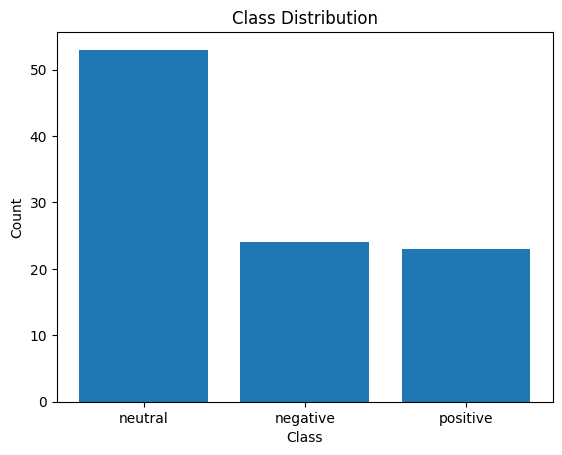

In [33]:
# plot the distribution of classes
label_counts = sampled_labelled_posts["label"].value_counts()
plt.bar(label_counts.index, label_counts.values)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

Here I create two functions that pass all posts through the RoBerta model and return all predicted sentiments. Since the model by Oliver Guhr facilitated this process by providing a method, I create a separate function for this model.

In [34]:
# create a function that automates BERT sentiment prediction
def bert_predict(df, text_column, model, tokenizer):

    # get all posts and create empty list for predictions
    all_posts = df[text_column]
    all_predictions = []

    # loop over all posts
    for post in all_posts:
        # get token ids and run them through the model
        input_tokens = tokenizer(post, return_tensors="pt", truncation=True, max_length=512)
        with torch.no_grad():
            outputs = model(**input_tokens)
        # turn logits into probabilities via softmax
        predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
        # get the predicted class and append to the list
        sentiment_classes = ["negative", "neutral", "positive"]
        predicted_class = sentiment_classes[predictions.argmax()]
        all_predictions.append(predicted_class)
    return all_predictions

# another helper function to run the function provided in package
def bert_predict_guhr(df, text_column, model):
    all_posts = df[text_column]
    all_predictions = model.predict_sentiment(all_posts)
    return all_predictions

I apply these functions to all posts and change the predicted sentiments in separate columns.

In [35]:
# apply prediction to all models and store labels in respective columns
sampled_labelled_posts["prediction_cardiffnlp"] = bert_predict(sampled_labelled_posts, "text", model_cardiffnlp, tokenizer_cardiffnlp)
sampled_labelled_posts["prediction_ssary"] = bert_predict(sampled_labelled_posts, "text", model_ssary, tokenizer_ssary)
sampled_labelled_posts["prediction_guhr"] = bert_predict_guhr(sampled_labelled_posts, "text", model_guhr)

# show the first few rows
sampled_labelled_posts.head()

,text,label,prediction_cardiffnlp,prediction_ssary,prediction_guhr
0,Die Union verspricht einen Industriestrompreis...,neutral,neutral,neutral,negative
1,"Für eine Politik, die verbindet statt spaltet,...",positive,positive,positive,neutral
2,"Danke, Jena, für die guten Gespräche heute auf...",positive,positive,neutral,neutral
3,(3/4) Rund 12 % der jungen Menschen in Deutsch...,negative,neutral,neutral,neutral
4,Richtiger und konsequenter Schritt der EU gege...,neutral,neutral,neutral,neutral


I show the basic classification reports for each model predictions. One can already see that the model by the Cardiff NLP group seems to perform best.

In [36]:
# extract the ground truth labels
y_true = sampled_labelled_posts["label"]

# loop over all models and print the classification report
models = ["cardiffnlp", "ssary", "guhr"]
for model in models:
    pred_col_name = "prediction_" + model
    y_pred = sampled_labelled_posts[pred_col_name]
    print(f"Classification report for {model}")
    print(classification_report(y_true, y_pred))
    print("-" * 60)

Classification report for cardiffnlp
              precision    recall  f1-score   support

    negative       0.76      0.67      0.71        24
     neutral       0.77      0.91      0.83        53
    positive       0.88      0.65      0.75        23

    accuracy                           0.79       100
   macro avg       0.81      0.74      0.77       100
weighted avg       0.80      0.79      0.79       100

------------------------------------------------------------
Classification report for ssary
              precision    recall  f1-score   support

    negative       0.70      0.29      0.41        24
     neutral       0.59      0.87      0.70        53
    positive       0.67      0.35      0.46        23

    accuracy                           0.61       100
   macro avg       0.65      0.50      0.52       100
weighted avg       0.63      0.61      0.58       100

------------------------------------------------------------
Classification report for guhr
              pr

To further plot the evaluation metrics I extract the exact numbers from the classification reports and save them in a compound df.

In [37]:
# define empty list to store all metrics in 
metrics_list = []

# loop over models
for model in models:

    # extract ground truth and predictions
    pred_col_name = "prediction_" + model
    y_true = sampled_labelled_posts["label"]
    y_pred = sampled_labelled_posts[pred_col_name]

    # get the classification report as dictionary
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    
    # loop over classes and store metrics
    for sentiment, metrics in report.items():
        # consider only metrics for the sentiments
        if sentiment in ["negative", "neutral", "positive"]:
            metrics_list.append({
                "model": model,
                "sentiment": sentiment,
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1": metrics["f1-score"]
            })

# convert to df and show first few rows
metrics_df = pd.DataFrame(metrics_list)
metrics_df.head()

,model,sentiment,precision,recall,f1
0,cardiffnlp,negative,0.761905,0.666667,0.711111
1,cardiffnlp,neutral,0.774194,0.905660,0.834783
2,cardiffnlp,positive,0.882353,0.652174,0.750000
3,ssary,negative,0.700000,0.291667,0.411765
4,ssary,neutral,0.589744,0.867925,0.702290


I create barplots that compare the model performance across precision, recall and F1 score. The plot confirms that the Cardiff NLP model works best across all evaluation metrics. The other two models seem to struggle most in terms of recall for the positive and negative class.

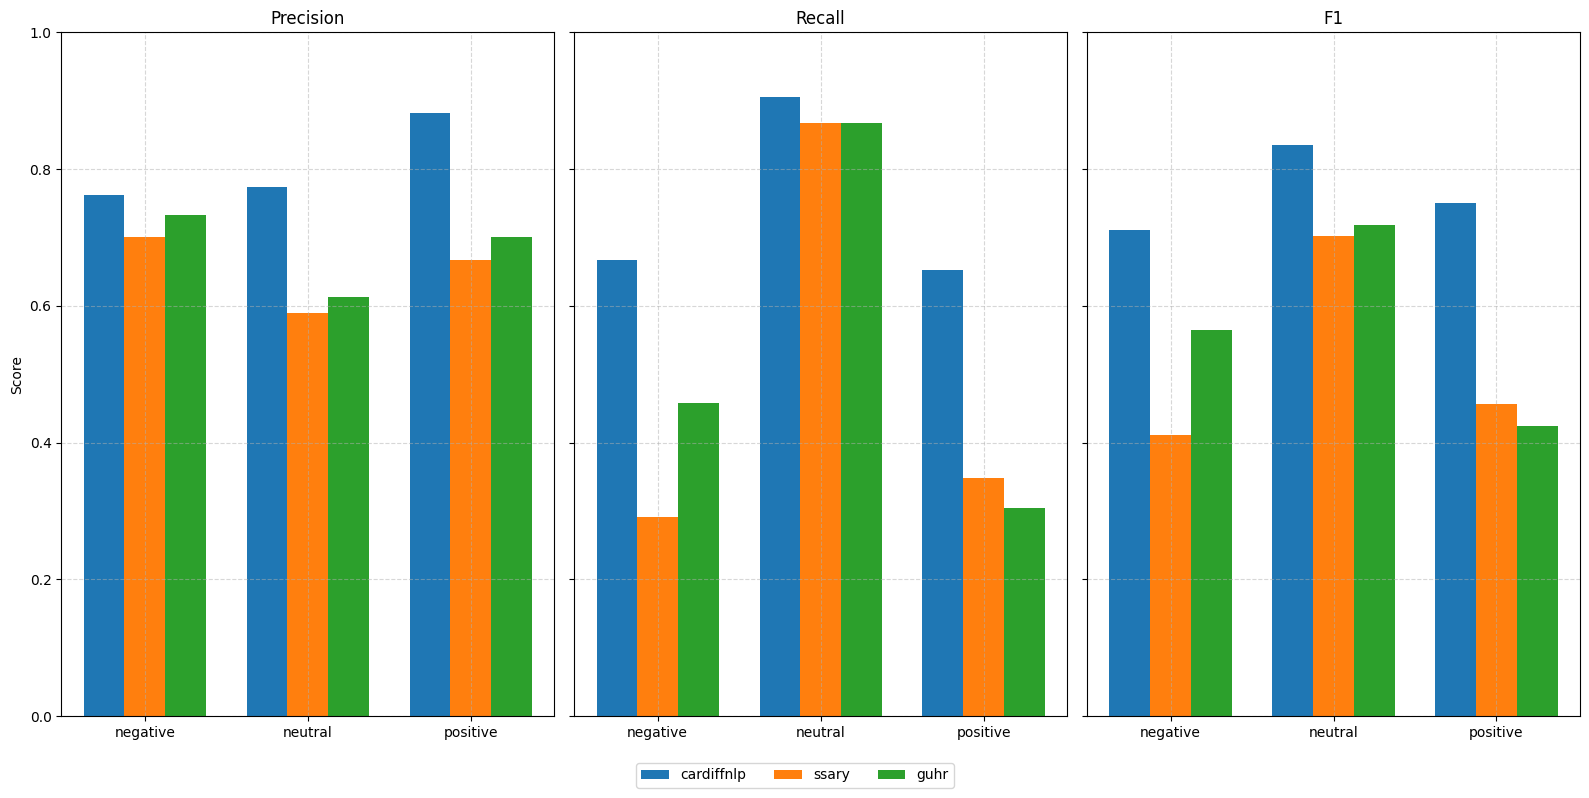

In [39]:
# create barplots to visualize the performance
metrics = ["precision", "recall", "f1"]
sentiments = ["negative", "neutral", "positive"]

cmap = plt.colormaps["tab10"]
colors = [cmap(i) for i in range(len(models))]

# create figure and axes for the plot
fig, axs = plt.subplots(1, 3, figsize=(16, 8), sharey=True)
width = 0.25
x = np.arange(3)

# loop over all metrics
for idx, metric in enumerate(metrics):
    ax = axs[idx]
    
    # loop over models and get the corresponding scores
    for i, model in enumerate(models):
        scores = metrics_df[metrics_df["model"] == model].set_index("sentiment")[metric].reindex(sentiments)
        ax.bar(x + i * width, scores, width=width, label=model, color=colors[i])
    
    # set title and configure the scale of the plot
    ax.set_title(metric.capitalize())
    ax.set_xticks(x + width)
    ax.set_xticklabels(sentiments)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel("Score" if idx == 0 else "")
    ax.grid(True, linestyle="--", alpha=0.5)

# add a legend underneath the plot
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=len(models))
plt.tight_layout(rect=[0, 0, 1, 0.95])

# save and show the plot
plt.savefig(
    "../02_figures_tables/classification_validation.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

I also extract the metrics giving information on the average model performance (macro scores and weighted averages).

In [18]:
# define empty list to store all metrics in 
avg_metrics_list = []

# loop over models
for model in models:

    # extract ground truth and predictions
    pred_col_name = "prediction_" + model
    y_true = sampled_labelled_posts["label"]
    y_pred = sampled_labelled_posts[pred_col_name]

    # get the classification report as dictionary
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    
    # loop over classes and store metrics
    for category, metrics in report.items():
        # consider only macro metrics
        if category in ["macro avg", "weighted avg"]:
            avg_metrics_list.append({
                "model": model,
                "category": category,
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1": metrics["f1-score"]
            })

# convert to df and show first few rows
avg_metrics_df = pd.DataFrame(avg_metrics_list)
avg_metrics_df.head()

,model,category,precision,recall,f1
0,cardiffnlp,macro avg,0.806150,0.741500,0.765298
1,cardiffnlp,weighted avg,0.796121,0.790000,0.785601
2,ssary,macro avg,0.652137,0.502472,0.523733
3,ssary,weighted avg,0.633897,0.610000,0.576180
4,guhr,macro avg,0.682222,0.543535,0.569032


The following barplots highlight that the model by Cardiff NLP performs best across all metrics.

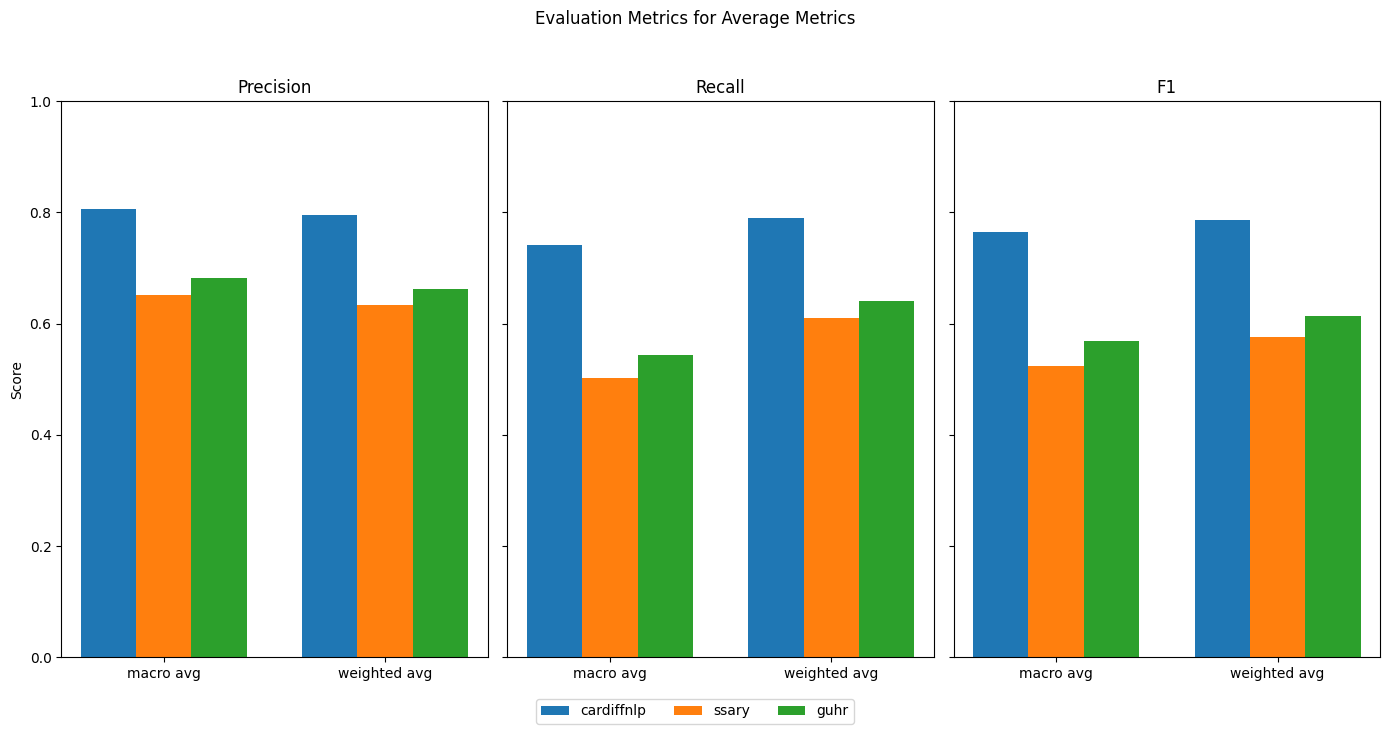

In [21]:
# plot the macro average and weighted average scores

# create barplots to visualize the performance
metrics = ["precision", "recall", "f1"]
categories = ["macro avg", "weighted avg"]

cmap = plt.colormaps["tab10"]
colors = [cmap(i) for i in range(len(models))]

# create figure and axes for the plot
fig, axs = plt.subplots(1, 3, figsize=(14, 7), sharey=True)
width = 0.25
x = np.arange(2)

# loop over all metrics
for idx, metric in enumerate(metrics):
    ax = axs[idx]
    
    # loop over all methods and get the corresponding scores
    for i, model in enumerate(models):
        scores = avg_metrics_df[avg_metrics_df["model"] == model].set_index("category")[metric].reindex(categories)
        ax.bar(x + i * width, scores, width=width, label=model, color=colors[i])
    
    # set title and configure the scale of the plot
    ax.set_title(metric.capitalize())
    ax.set_xticks(x + width)
    ax.set_xticklabels(categories)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel("Score" if idx == 0 else "")

# add a legend underneath the plot
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=len(models))
fig.suptitle("Evaluation Metrics for Average Metrics")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

To get further insights into the model predictions I create confusion matrices. These show nicely that the models by Guhr and Ssary struggled the most in recognizing positive and negative posts. The models predominantly predicted the neutral class in these cases. This led to lower recall values for these classes.

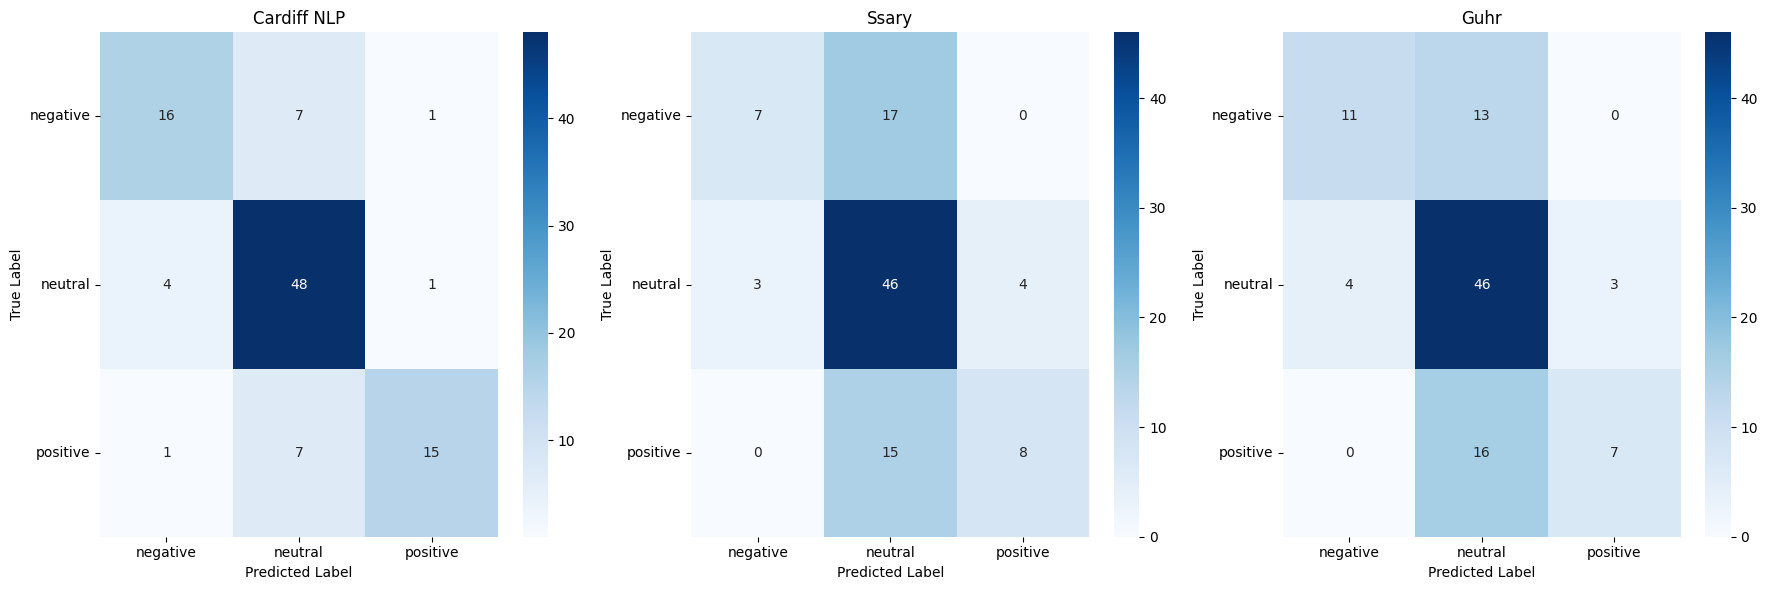

In [28]:
# create confusion matrices

# extract the ground truth as well as all predictions
true_label = sampled_labelled_posts["label"]
cardiff_pred = sampled_labelled_posts["prediction_cardiffnlp"]
ssary_pred = sampled_labelled_posts["prediction_ssary"]
guhr_pred = sampled_labelled_posts["prediction_guhr"]
labels = sorted(sampled_labelled_posts["label"].unique())

# call the confusion matrix method from sklearn
cm_cardiff = confusion_matrix(true_label, cardiff_pred, labels=labels)
cm_ssary = confusion_matrix(true_label, ssary_pred, labels=labels)
cm_guhr = confusion_matrix(true_label, guhr_pred, labels=labels)

# create the confusion matrices plots with seaborn
cms = [cm_cardiff, cm_ssary, cm_guhr]
titles = ['Cardiff NLP', 'Ssary', 'Guhr']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# loop over confusion matrices and create the plot with seaborn
for ax, cm, title in zip(axes, cms, titles):
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
        cbar=True
    )
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title(title)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y', rotation=0)
plt.tight_layout()

# save and show the plot
plt.savefig("../02_figures_tables/confusion_matrices.png", dpi=300)
plt.show()